# Experiment 2.0 — SNN trainability / small-subset overfit sanity check

## Goal

Before comparing training objectives, readouts, width, or depth, verify that the simple feed-forward SNN can **memorize a deliberately small balanced training subset**.

\[
\boxed{\text{If a tiny subset cannot be overfit, do not interpret later capacity sweeps.}}
\]

Fixed backbone:

\[
C \rightarrow 64 \rightarrow 64 \rightarrow K
\]

with unsigned polarity-split events, dynamic input channel count, no recurrence, fixed single \(\tau_{syn}\), fixed \(\tau_{mem}\), fixed threshold, and **no SNN Linear bias**.

The default canary objective is `fixed_200ms_ce`, because it preserves temporal structure while remaining causal / streaming-friendly. It can be changed to any A–F objective used in Experiment 2.1.

Default pass criterion:

\[
Train\ Balanced\ Accuracy \ge 0.80
\]

on the same small subset used for optimization.


In [1]:
from __future__ import annotations

from pathlib import Path
import copy, hashlib, json, math, os, random, sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from IPython.display import display

import snntorch as snn
from snntorch import surrogate
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "snn").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the writingRing repository root")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from snn.accel_reconstruction_eval.datasets import load_acceleration_data

print("Repository root:", REPO_ROOT)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Repository root: /home/ted/project/writingring-viz
PyTorch: 2.11.0+cu130
CUDA available: True


## 1. Configuration

In [2]:
DATASET_ROOTS = [
    REPO_ROOT / "outputs/action0_wavelets_1_2_4_8_16",
    REPO_ROOT / "outputs/action1_wavelets_1_2_4_8_16",
]

INCLUDED_LABELS = (
    "A", "B", "C", "D", "E", "X",
    "G", "H", "I", "J", "K", "L",
)

SPLIT_SEED = 12345
TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15

OVERFIT_SEED = 11
SUBSET_SEED = 20260823
OVERFIT_SAMPLES_PER_CLASS = 8

BATCH_SIZE = 32
NUM_WORKERS = 0
OVERFIT_EPOCHS = 100
LEARNING_RATE = 5e-4
WEIGHT_DECAY = 0.0
GRAD_CLIP_NORM = None

PASS_TRAIN_BA = 0.80
FIRING_ONSET_THRESHOLD = 1e-3

# Default: causal temporal objective.
OVERFIT_OBJECTIVE = "fixed_200ms_ce"

HIDDEN_WIDTH = 64
N_RELATIVE_BINS = 10
FIXED_BIN_MS = 200.0
HYBRID_COUNT_WEIGHT = 0.1

TAU_SYN_MS = 77.47
TAU_MEM_MS = 7.213
THRESHOLD = 1.0
SURROGATE_SLOPE = 25.0
RESET_MECHANISM = "subtract"

SPIKE_REGULARIZATION = 0.0
ZERO_INPUT_DIAGNOSTIC_STEPS = 200

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

EXPERIMENT_ID = "experiment_2_0_snn_overfit_trainability"
RESULTS_DIR = (
    REPO_ROOT / "notebooks/artifacts/experiment_2_0_snn_overfit_trainability"
)

print("Objective:", OVERFIT_OBJECTIVE)
print("Device:", DEVICE)


Objective: fixed_200ms_ce
Device: cuda


## 2. Reproducibility

In [3]:
def derive_seed(master_seed: int, *parts: object) -> int:
    text = "|".join([str(master_seed), *(str(p) for p in parts)])
    digest = hashlib.sha256(text.encode("utf-8")).digest()
    return int.from_bytes(digest[:4], "little", signed=False)


def seed_everything(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except TypeError:
        torch.use_deterministic_algorithms(True)


def worker_init_fn(worker_id: int) -> None:
    worker_seed = torch.initial_seed() % (2**32)
    random.seed(worker_seed)
    np.random.seed(worker_seed)


## 3. Load and validate unsigned dynamic-channel event data

In [4]:
data = load_acceleration_data(
    DATASET_ROOTS,
    repository_root=REPO_ROOT,
    require_reconstruction=False,
)

sampling_rates = {float(m.sampling_rate_hz) for m in data.producer_metadatas}
if len(sampling_rates) != 1:
    raise ValueError(f"Expected one shared sampling rate, got {sampling_rates}")
SAMPLING_RATE_HZ = sampling_rates.pop()

event_contracts = set()
for metadata in data.producer_metadatas:
    raw = metadata.raw
    event_representation = raw.get("event_representation")
    event_feature_schema = raw.get("event_feature_schema")
    event_channel_count = raw.get("event_channel_count")
    encoder_spec_sha256 = raw.get("spike_encoder_spec_sha256")

    if event_representation != "unsigned":
        raise ValueError(
            "Requires event_representation='unsigned'; "
            f"got {event_representation!r}"
        )
    if not isinstance(event_feature_schema, str) or not event_feature_schema:
        raise ValueError("Missing event_feature_schema")
    if not isinstance(event_channel_count, int) or event_channel_count <= 0:
        raise ValueError("event_channel_count must be positive")
    if event_channel_count != metadata.channel_count - 6:
        raise ValueError(
            "Expected six auxiliary IMU channels after event channels; "
            f"event={event_channel_count}, total={metadata.channel_count}"
        )
    if not isinstance(encoder_spec_sha256, str) or len(encoder_spec_sha256) != 64:
        raise ValueError("Missing spike_encoder_spec_sha256")

    event_contracts.add(
        (
            event_representation,
            event_feature_schema,
            event_channel_count,
            encoder_spec_sha256,
        )
    )

if len(event_contracts) != 1:
    raise ValueError(f"Incompatible event contracts: {event_contracts}")

(
    EVENT_REPRESENTATION,
    EVENT_FEATURE_SCHEMA,
    INPUT_CHANNELS,
    ENCODER_SPEC_SHA256,
) = event_contracts.pop()

rows = []
included = None if INCLUDED_LABELS is None else set(map(str, INCLUDED_LABELS))
padded_lengths = set()

for package_index, package in enumerate(data.packages):
    padded_lengths.add(int(package.padded_spike_imu.shape[1]))

    for segment_index, label in enumerate(package.labels.astype(str)):
        label = str(label)
        if included is not None and label not in included:
            continue

        valid_length = int(package.valid_lengths[segment_index])
        if valid_length <= 0:
            raise ValueError("valid_length must be positive")

        event_values = np.asarray(
            package.padded_spike_imu[
                segment_index, :valid_length, :INPUT_CHANNELS
            ]
        )
        if np.any(~np.isfinite(event_values)):
            raise ValueError("Non-finite event values")
        if np.any(event_values < 0.0):
            raise ValueError(
                f"Unsigned event contract violated for "
                f"{package.user}/action_{package.action}/{segment_index}"
            )

        rows.append(
            {
                "package_index": package_index,
                "segment_index": segment_index,
                "user": str(package.user),
                "action": str(package.action),
                "label": label,
                "valid_length": valid_length,
                "sample_id": f"{package.user}/action_{package.action}/{segment_index}",
            }
        )

if len(padded_lengths) != 1:
    raise ValueError(f"Expected one padded length, got {padded_lengths}")
PADDED_LENGTH = padded_lengths.pop()

manifest = pd.DataFrame(rows)
if manifest.empty:
    raise ValueError("No samples remain after label filtering")

labels_sorted = sorted(manifest["label"].unique().tolist())
CLASS_TO_IDX = {label: i for i, label in enumerate(labels_sorted)}
manifest["label_idx"] = manifest["label"].map(CLASS_TO_IDX).astype(int)
NUM_CLASSES = len(CLASS_TO_IDX)

DT_MS = 1000.0 / SAMPLING_RATE_HZ
ALPHA = float(math.exp(-DT_MS / TAU_SYN_MS))
BETA = float(math.exp(-DT_MS / TAU_MEM_MS))

FIXED_BIN_STEPS = max(
    1,
    int(round(FIXED_BIN_MS * SAMPLING_RATE_HZ / 1000.0)),
)
FIXED_BIN_COUNT = int(math.ceil(PADDED_LENGTH / FIXED_BIN_STEPS))

print(f"Samples: {len(manifest):,}")
print("Users:", manifest.user.nunique())
print("Classes:", NUM_CLASSES, labels_sorted)
print("Input event channels:", INPUT_CHANNELS)
print("Sampling rate:", SAMPLING_RATE_HZ, "Hz")
print("Padded length:", PADDED_LENGTH)
print(
    f"Fixed bin: {FIXED_BIN_MS:.1f} ms = "
    f"{FIXED_BIN_STEPS} samples, {FIXED_BIN_COUNT} bins"
)
print(f"alpha={ALPHA:.6f}, beta={BETA:.6f}, threshold={THRESHOLD}")


Samples: 911
Users: 20
Classes: 12 ['A', 'B', 'C', 'D', 'E', 'G', 'H', 'I', 'J', 'K', 'L', 'X']
Input event channels: 30
Sampling rate: 200.0 Hz
Padded length: 600
Fixed bin: 200.0 ms = 40 samples, 15 bins
alpha=0.937498, beta=0.499977, threshold=1.0


## 4. Fixed user-disjoint split

In [5]:
def make_user_split(manifest: pd.DataFrame) -> pd.DataFrame:
    users = sorted(manifest["user"].unique().tolist())
    rng = np.random.default_rng(SPLIT_SEED)
    perm = np.array(users, dtype=object)
    rng.shuffle(perm)

    n = len(perm)
    n_train = max(1, int(np.floor(TRAIN_FRACTION * n)))
    n_val = max(1, int(np.floor(VAL_FRACTION * n)))
    if n_train + n_val >= n:
        n_train, n_val = n - 2, 1

    train_users = set(perm[:n_train].tolist())
    val_users = set(perm[n_train:n_train + n_val].tolist())

    out = manifest.copy()
    out["split"] = out["user"].map(
        lambda u: "train" if u in train_users else (
            "val" if u in val_users else "test"
        )
    )
    return out


FIXED_SPLIT_MANIFEST = make_user_split(manifest)

display(
    FIXED_SPLIT_MANIFEST.groupby("split").agg(
        users=("user", "nunique"),
        samples=("label", "size"),
        classes_present=("label", "nunique"),
    )
)


,users,samples,classes_present
split,,,
test,3,167,12
train,14,619,12
val,3,125,12


## 5. Construct a small balanced train-only subset

In [6]:
train_manifest = FIXED_SPLIT_MANIFEST[
    FIXED_SPLIT_MANIFEST.split == "train"
].copy()

rng = np.random.default_rng(SUBSET_SEED)
subset_parts = []
actual_per_class = {}

for label in labels_sorted:
    class_rows = train_manifest[train_manifest.label == label].copy()

    if class_rows.empty:
        raise ValueError(f"Train split contains no samples for class {label!r}")

    take = min(OVERFIT_SAMPLES_PER_CLASS, len(class_rows))
    chosen_idx = rng.choice(
        class_rows.index.to_numpy(),
        size=take,
        replace=False,
    )

    subset_parts.append(class_rows.loc[chosen_idx].copy())
    actual_per_class[label] = take

OVERFIT_MANIFEST = (
    pd.concat(subset_parts, ignore_index=True)
    .sample(frac=1.0, random_state=SUBSET_SEED)
    .reset_index(drop=True)
)

print("Overfit subset samples:", len(OVERFIT_MANIFEST))
print("Samples per class:", actual_per_class)
display(OVERFIT_MANIFEST.groupby("label").size().rename("count"))


Overfit subset samples: 96
Samples per class: {'A': 8, 'B': 8, 'C': 8, 'D': 8, 'E': 8, 'G': 8, 'H': 8, 'I': 8, 'J': 8, 'K': 8, 'L': 8, 'X': 8}


label
A    8
B    8
C    8
D    8
E    8
G    8
H    8
I    8
J    8
K    8
L    8
X    8
Name: count, dtype: int64

## 6. Dataset / DataLoader

In [7]:
class EventSNNDataset(Dataset):
    def __init__(self, data, subset_manifest: pd.DataFrame):
        self.data = data
        self.df = subset_manifest.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        row = self.df.iloc[index]
        package = self.data.packages[int(row.package_index)]
        segment_index = int(row.segment_index)
        valid_length = int(row.valid_length)

        x = np.asarray(
            package.padded_spike_imu[
                segment_index, :, :INPUT_CHANNELS
            ],
            dtype=np.float32,
        ).copy()

        if x.shape != (PADDED_LENGTH, INPUT_CHANNELS):
            raise ValueError(f"Unexpected input shape {x.shape}")
        if np.any(x[:valid_length] < 0.0):
            raise ValueError("Unsigned event contract violated")

        x[valid_length:] = 0.0
        valid_mask = np.arange(PADDED_LENGTH) < valid_length

        return {
            "x": torch.from_numpy(x),
            "label": torch.tensor(int(row.label_idx), dtype=torch.long),
            "valid_mask": torch.from_numpy(valid_mask),
            "valid_length": torch.tensor(valid_length, dtype=torch.long),
            "sample_id": str(row.sample_id),
        }


def make_loader(
    subset_manifest: pd.DataFrame,
    *,
    batch_size: int,
    shuffle: bool,
    seed: int,
):
    dataset = EventSNNDataset(data, subset_manifest)
    generator = torch.Generator().manual_seed(seed)

    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        generator=generator,
        worker_init_fn=worker_init_fn if NUM_WORKERS > 0 else None,
        pin_memory=torch.cuda.is_available(),
    )


In [8]:
train_loader = make_loader(
    OVERFIT_MANIFEST,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=derive_seed(OVERFIT_SEED, "overfit_train_loader"),
)

eval_loader = make_loader(
    OVERFIT_MANIFEST,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=derive_seed(OVERFIT_SEED, "overfit_eval_loader"),
)


## 7. Temporal aggregation helpers

In [9]:
def relative_temporal_bin_counts(
    output_spikes: torch.Tensor,
    valid_lengths: torch.Tensor,
    n_bins: int,
) -> torch.Tensor:
    _, time_steps, _ = output_spikes.shape
    lengths = valid_lengths.to(output_spikes.device, dtype=torch.long)

    t = torch.arange(time_steps, device=output_spikes.device)[None, :]
    valid = t < lengths[:, None]

    bin_index = torch.div(
        t * n_bins,
        lengths[:, None],
        rounding_mode="floor",
    ).clamp_max(n_bins - 1)

    one_hot = F.one_hot(
        bin_index,
        num_classes=n_bins,
    ).to(output_spikes.dtype)

    one_hot = one_hot * valid.unsqueeze(-1).to(output_spikes.dtype)
    return torch.einsum("btn,btk->bnk", one_hot, output_spikes)


def fixed_duration_bin_counts(
    output_spikes: torch.Tensor,
    valid_mask: torch.Tensor,
) -> torch.Tensor:
    batch_size, time_steps, class_count = output_spikes.shape
    masked = output_spikes * valid_mask.unsqueeze(-1).to(output_spikes.dtype)

    target_steps = FIXED_BIN_COUNT * FIXED_BIN_STEPS
    if target_steps > time_steps:
        masked = F.pad(masked, (0, 0, 0, target_steps - time_steps))

    return masked.reshape(
        batch_size,
        FIXED_BIN_COUNT,
        FIXED_BIN_STEPS,
        class_count,
    ).sum(dim=2)


def last_fixed_window_counts(
    output_spikes: torch.Tensor,
    valid_lengths: torch.Tensor,
) -> torch.Tensor:
    _, time_steps, _ = output_spikes.shape
    lengths = valid_lengths.to(output_spikes.device, dtype=torch.long)

    t = torch.arange(time_steps, device=output_spikes.device)[None, :]
    start = (lengths - FIXED_BIN_STEPS).clamp_min(0)

    window_mask = (
        (t >= start[:, None])
        & (t < lengths[:, None])
    )

    return (
        output_spikes
        * window_mask.unsqueeze(-1).to(output_spikes.dtype)
    ).sum(dim=1)


## 8. Fixed no-bias SNN

In [10]:
class SharedBackboneSNN(nn.Module):
    def __init__(self, num_classes: int, input_channels: int):
        super().__init__()

        self.num_classes = int(num_classes)
        self.input_channels = int(input_channels)

        spike_grad = surrogate.fast_sigmoid(slope=SURROGATE_SLOPE)

        self.fc1 = nn.Linear(input_channels, HIDDEN_WIDTH, bias=False)
        self.lif1 = snn.Synaptic(
            alpha=ALPHA,
            beta=BETA,
            threshold=THRESHOLD,
            spike_grad=spike_grad,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
            reset_mechanism=RESET_MECHANISM,
        )

        self.fc2 = nn.Linear(HIDDEN_WIDTH, HIDDEN_WIDTH, bias=False)
        self.lif2 = snn.Synaptic(
            alpha=ALPHA,
            beta=BETA,
            threshold=THRESHOLD,
            spike_grad=spike_grad,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
            reset_mechanism=RESET_MECHANISM,
        )

        self.fc_out = nn.Linear(HIDDEN_WIDTH, num_classes, bias=False)
        self.lif_out = snn.Synaptic(
            alpha=ALPHA,
            beta=BETA,
            threshold=THRESHOLD,
            spike_grad=spike_grad,
            learn_alpha=False,
            learn_beta=False,
            learn_threshold=False,
            reset_mechanism=RESET_MECHANISM,
        )

    @property
    def backbone_parameter_count(self):
        return sum(p.numel() for p in self.parameters())

    @property
    def spike_neuron_count(self):
        return 2 * HIDDEN_WIDTH + self.num_classes

    def forward(self, x, valid_mask):
        self.lif1.reset_mem()
        self.lif2.reset_mem()
        self.lif_out.reset_mem()

        spk1_rec, spk2_rec, spk_out_rec, mem_out_rec = [], [], [], []

        for step in range(x.shape[1]):
            spk1, _, _ = self.lif1(self.fc1(x[:, step, :]))
            spk2, _, _ = self.lif2(self.fc2(spk1))
            spk_out, _, mem_out = self.lif_out(self.fc_out(spk2))

            spk1_rec.append(spk1)
            spk2_rec.append(spk2)
            spk_out_rec.append(spk_out)
            mem_out_rec.append(mem_out)

        spk1_rec = torch.stack(spk1_rec, dim=1)
        spk2_rec = torch.stack(spk2_rec, dim=1)
        spk_out_rec = torch.stack(spk_out_rec, dim=1)
        mem_out_rec = torch.stack(mem_out_rec, dim=1)

        mask_f = valid_mask.unsqueeze(-1).to(spk_out_rec.dtype)
        total_valid_spikes = (
            (spk1_rec * mask_f).sum()
            + (spk2_rec * mask_f).sum()
            + (spk_out_rec * mask_f).sum()
        )

        return {
            "spk1": spk1_rec,
            "spk2": spk2_rec,
            "output_spikes": spk_out_rec,
            "output_membrane": mem_out_rec,
            "total_valid_spikes": total_valid_spikes,
        }


## 9. A–F objective implementations

In [11]:
OBJECTIVE_NAMES = (
    "timestep_ce",
    "whole_count_ce",
    "relative_10bin_ce",
    "hybrid_relative10bin_count",
    "fixed_200ms_ce",
    "last_200ms_ce",
)


def masked_timestep_ce(output_spikes, labels, valid_mask):
    batch_size, time_steps, class_count = output_spikes.shape
    targets = labels[:, None].expand(batch_size, time_steps)

    loss_per_step = F.cross_entropy(
        output_spikes.reshape(batch_size * time_steps, class_count),
        targets.reshape(batch_size * time_steps),
        reduction="none",
    ).reshape(batch_size, time_steps)

    mask_f = valid_mask.to(loss_per_step.dtype)
    return (
        (loss_per_step * mask_f).sum()
        / mask_f.sum().clamp_min(1)
    )


class ObjectiveSNN(nn.Module):
    def __init__(self, objective, num_classes, input_channels, master_seed):
        super().__init__()

        if objective not in OBJECTIVE_NAMES:
            raise ValueError(f"Unknown objective {objective!r}")

        self.objective = objective
        self.num_classes = int(num_classes)

        seed_everything(derive_seed(master_seed, "shared_backbone_init"))
        self.backbone = SharedBackboneSNN(
            num_classes=num_classes,
            input_channels=input_channels,
        )

        self.readout_head = None

        if objective in {
            "relative_10bin_ce",
            "hybrid_relative10bin_count",
        }:
            seed_everything(derive_seed(master_seed, objective, "head_init"))
            self.readout_head = nn.Linear(
                N_RELATIVE_BINS * num_classes,
                num_classes,
                bias=True,
            )

        elif objective == "fixed_200ms_ce":
            seed_everything(derive_seed(master_seed, objective, "head_init"))
            self.readout_head = nn.Linear(
                FIXED_BIN_COUNT * num_classes,
                num_classes,
                bias=True,
            )

    @property
    def backbone_parameter_count(self):
        return self.backbone.backbone_parameter_count

    @property
    def readout_parameter_count(self):
        if self.readout_head is None:
            return 0
        return sum(p.numel() for p in self.readout_head.parameters())

    @property
    def total_parameter_count(self):
        return sum(p.numel() for p in self.parameters())

    def forward(self, x, valid_mask):
        return self.backbone(x, valid_mask)

    def full_counts(self, out, valid_mask):
        return (
            out["output_spikes"]
            * valid_mask.unsqueeze(-1).to(out["output_spikes"].dtype)
        ).sum(dim=1)

    def native_logits(self, out, valid_mask, valid_lengths):
        full_counts = self.full_counts(out, valid_mask)

        if self.objective in {"timestep_ce", "whole_count_ce"}:
            return full_counts

        if self.objective in {
            "relative_10bin_ce",
            "hybrid_relative10bin_count",
        }:
            bins = relative_temporal_bin_counts(
                out["output_spikes"],
                valid_lengths,
                N_RELATIVE_BINS,
            )
            return self.readout_head(bins.flatten(start_dim=1))

        if self.objective == "fixed_200ms_ce":
            bins = fixed_duration_bin_counts(
                out["output_spikes"],
                valid_mask,
            )
            return self.readout_head(bins.flatten(start_dim=1))

        if self.objective == "last_200ms_ce":
            return last_fixed_window_counts(
                out["output_spikes"],
                valid_lengths,
            )

        raise RuntimeError(self.objective)

    def training_loss(self, out, labels, valid_mask, valid_lengths):
        full_counts = self.full_counts(out, valid_mask)

        if self.objective == "timestep_ce":
            loss = masked_timestep_ce(
                out["output_spikes"],
                labels,
                valid_mask,
            )

        elif self.objective == "whole_count_ce":
            loss = F.cross_entropy(full_counts, labels)

        elif self.objective == "relative_10bin_ce":
            loss = F.cross_entropy(
                self.native_logits(out, valid_mask, valid_lengths),
                labels,
            )

        elif self.objective == "hybrid_relative10bin_count":
            loss = (
                F.cross_entropy(
                    self.native_logits(out, valid_mask, valid_lengths),
                    labels,
                )
                + HYBRID_COUNT_WEIGHT
                * F.cross_entropy(full_counts, labels)
            )

        elif self.objective == "fixed_200ms_ce":
            loss = F.cross_entropy(
                self.native_logits(out, valid_mask, valid_lengths),
                labels,
            )

        elif self.objective == "last_200ms_ce":
            loss = F.cross_entropy(
                self.native_logits(out, valid_mask, valid_lengths),
                labels,
            )

        else:
            raise RuntimeError(self.objective)

        if SPIKE_REGULARIZATION > 0:
            valid_neuron_time = (
                valid_mask.to(out["output_spikes"].dtype).sum().clamp_min(1)
                * self.backbone.spike_neuron_count
            )
            loss = (
                loss
                + SPIKE_REGULARIZATION
                * out["total_valid_spikes"]
                / valid_neuron_time
            )

        return loss


## 10. Metrics / zero-input diagnostic

In [13]:
def classification_metrics(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(
            balanced_accuracy_score(y_true, y_pred)
        ),
        "macro_f1": float(
            f1_score(y_true, y_pred, average="macro", zero_division=0)
        ),
    }


@torch.no_grad()
def evaluate_objective_model(model, loader):
    model.eval()

    y_true, y_pred = [], []
    total_loss = 0.0
    sample_count = 0
    valid_steps = 0
    l1_spikes = l2_spikes = output_spikes = 0.0
    silent_output_samples = 0

    for batch in loader:
        x = batch["x"].to(DEVICE, non_blocking=True)
        y = batch["label"].to(DEVICE, non_blocking=True)
        mask = batch["valid_mask"].to(DEVICE, non_blocking=True)
        lengths = batch["valid_length"].to(DEVICE, non_blocking=True)

        out = model(x, mask)
        loss = model.training_loss(out, y, mask, lengths)
        logits = model.native_logits(out, mask, lengths)
        pred = logits.argmax(dim=1)

        batch_size = len(y)
        batch_valid_steps = int(mask.sum().item())

        total_loss += float(loss.item()) * batch_size
        sample_count += batch_size
        valid_steps += batch_valid_steps

        y_true.extend(y.cpu().tolist())
        y_pred.extend(pred.cpu().tolist())

        mask_f = mask.unsqueeze(-1).to(out["output_spikes"].dtype)
        batch_l1 = (out["spk1"] * mask_f).sum(dim=(1, 2))
        batch_l2 = (out["spk2"] * mask_f).sum(dim=(1, 2))
        batch_out = (out["output_spikes"] * mask_f).sum(dim=(1, 2))

        l1_spikes += float(batch_l1.sum().item())
        l2_spikes += float(batch_l2.sum().item())
        output_spikes += float(batch_out.sum().item())
        silent_output_samples += int((batch_out == 0).sum().item())

    metrics = classification_metrics(y_true, y_pred)
    metrics["loss"] = total_loss / max(sample_count, 1)
    metrics["l1_firing_rate"] = (
        l1_spikes / max(valid_steps * HIDDEN_WIDTH, 1)
    )
    metrics["l2_firing_rate"] = (
        l2_spikes / max(valid_steps * HIDDEN_WIDTH, 1)
    )
    metrics["output_firing_rate"] = (
        output_spikes / max(valid_steps * NUM_CLASSES, 1)
    )
    metrics["network_firing_rate"] = (
        (l1_spikes + l2_spikes + output_spikes)
        / max(valid_steps * (2 * HIDDEN_WIDTH + NUM_CLASSES), 1)
    )
    metrics["silent_output_fraction"] = (
        silent_output_samples / max(sample_count, 1)
    )
    metrics["samples"] = sample_count
    return metrics


@torch.no_grad()
def zero_input_activity(model, steps=ZERO_INPUT_DIAGNOSTIC_STEPS):
    model.eval()

    x = torch.zeros(
        1,
        steps,
        INPUT_CHANNELS,
        device=DEVICE,
    )
    mask = torch.ones(
        1,
        steps,
        dtype=torch.bool,
        device=DEVICE,
    )

    out = model(x, mask)

    return {
        "zero_l1_firing_rate": float(out["spk1"].mean().item()),
        "zero_l2_firing_rate": float(out["spk2"].mean().item()),
        "zero_output_firing_rate": float(
            out["output_spikes"].mean().item()
        ),
    }


## 11. Run the overfit test

In [14]:
if OVERFIT_OBJECTIVE not in OBJECTIVE_NAMES:
    raise ValueError(
        f"OVERFIT_OBJECTIVE must be one of {OBJECTIVE_NAMES}; "
        f"got {OVERFIT_OBJECTIVE!r}"
    )

model = ObjectiveSNN(
    objective=OVERFIT_OBJECTIVE,
    num_classes=NUM_CLASSES,
    input_channels=INPUT_CHANNELS,
    master_seed=OVERFIT_SEED,
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print(
    f"Architecture: {INPUT_CHANNELS} -> {HIDDEN_WIDTH} -> "
    f"{HIDDEN_WIDTH} -> {NUM_CLASSES}"
)
print("Backbone params:", model.backbone_parameter_count)
print("Readout params:", model.readout_parameter_count)
print("Total params:", model.total_parameter_count)

zero_before = zero_input_activity(model)
print("Zero-input BEFORE training:", zero_before)

history_rows = []
best_train_ba = -np.inf
best_epoch = -1
firing_onset_epoch = None

for epoch in range(1, OVERFIT_EPOCHS + 1):
    model.train()

    for batch in train_loader:
        x = batch["x"].to(DEVICE, non_blocking=True)
        y = batch["label"].to(DEVICE, non_blocking=True)
        mask = batch["valid_mask"].to(DEVICE, non_blocking=True)
        lengths = batch["valid_length"].to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        out = model(x, mask)
        loss = model.training_loss(out, y, mask, lengths)

        if not torch.isfinite(loss):
            raise FloatingPointError("Non-finite overfit loss")

        loss.backward()

        if GRAD_CLIP_NORM is not None:
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                GRAD_CLIP_NORM,
            )

        optimizer.step()

    metrics = evaluate_objective_model(model, eval_loader)

    if (
        firing_onset_epoch is None
        and metrics["output_firing_rate"] > FIRING_ONSET_THRESHOLD
    ):
        firing_onset_epoch = epoch

    if metrics["balanced_accuracy"] > best_train_ba:
        best_train_ba = metrics["balanced_accuracy"]
        best_epoch = epoch

    history_rows.append(
        {
            "epoch": epoch,
            "train_loss": metrics["loss"],
            "train_accuracy": metrics["accuracy"],
            "train_balanced_accuracy": metrics["balanced_accuracy"],
            "train_macro_f1": metrics["macro_f1"],
            "l1_firing_rate": metrics["l1_firing_rate"],
            "l2_firing_rate": metrics["l2_firing_rate"],
            "output_firing_rate": metrics["output_firing_rate"],
            "silent_output_fraction": metrics["silent_output_fraction"],
        }
    )

    if epoch == 1 or epoch % 5 == 0 or epoch == OVERFIT_EPOCHS:
        print(
            f"epoch {epoch:>3d} | "
            f"loss={metrics['loss']:.4f} | "
            f"train BA={metrics['balanced_accuracy']:.4f} | "
            f"out FR={metrics['output_firing_rate']:.4f}"
        )

history = pd.DataFrame(history_rows)
zero_after = zero_input_activity(model)

PASSED = bool(best_train_ba >= PASS_TRAIN_BA)

print()
print("Best train BA:", best_train_ba, "at epoch", best_epoch)
print("Firing onset epoch:", firing_onset_epoch)
print("Zero-input AFTER training:", zero_after)
print("PASS" if PASSED else "FAIL")


Architecture: 30 -> 64 -> 64 -> 12
Backbone params: 6784
Readout params: 2172
Total params: 8956
Zero-input BEFORE training: {'zero_l1_firing_rate': 0.0, 'zero_l2_firing_rate': 0.0, 'zero_output_firing_rate': 0.0}
epoch   1 | loss=2.4856 | train BA=0.0833 | out FR=0.0000
epoch   5 | loss=2.4769 | train BA=0.0938 | out FR=0.0001
epoch  10 | loss=2.4484 | train BA=0.1042 | out FR=0.0004
epoch  15 | loss=2.4229 | train BA=0.1250 | out FR=0.0008
epoch  20 | loss=2.3722 | train BA=0.1250 | out FR=0.0015
epoch  25 | loss=2.2891 | train BA=0.1875 | out FR=0.0027
epoch  30 | loss=2.2009 | train BA=0.1979 | out FR=0.0043
epoch  35 | loss=2.1492 | train BA=0.2188 | out FR=0.0052
epoch  40 | loss=2.1046 | train BA=0.2396 | out FR=0.0062
epoch  45 | loss=2.0730 | train BA=0.2396 | out FR=0.0078
epoch  50 | loss=2.0090 | train BA=0.2500 | out FR=0.0099
epoch  55 | loss=1.9558 | train BA=0.3021 | out FR=0.0112
epoch  60 | loss=1.8812 | train BA=0.3229 | out FR=0.0143
epoch  65 | loss=1.8298 | train 

## 12. Visualization

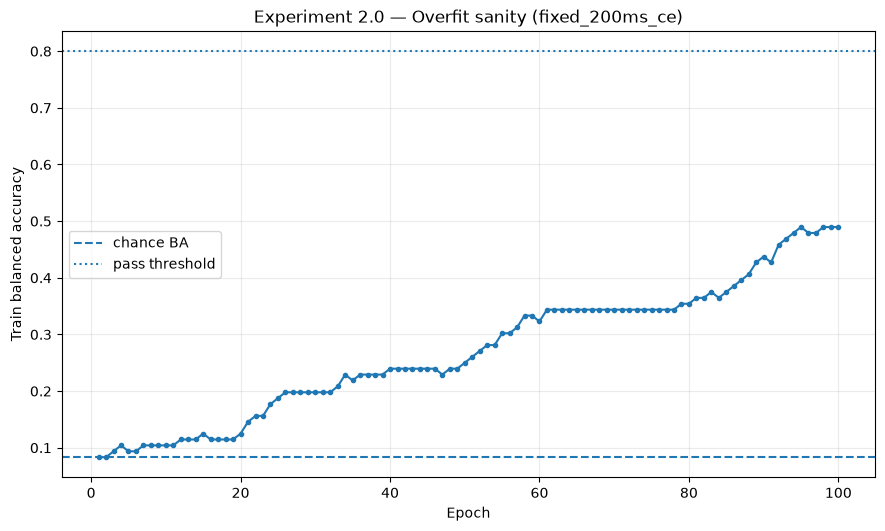

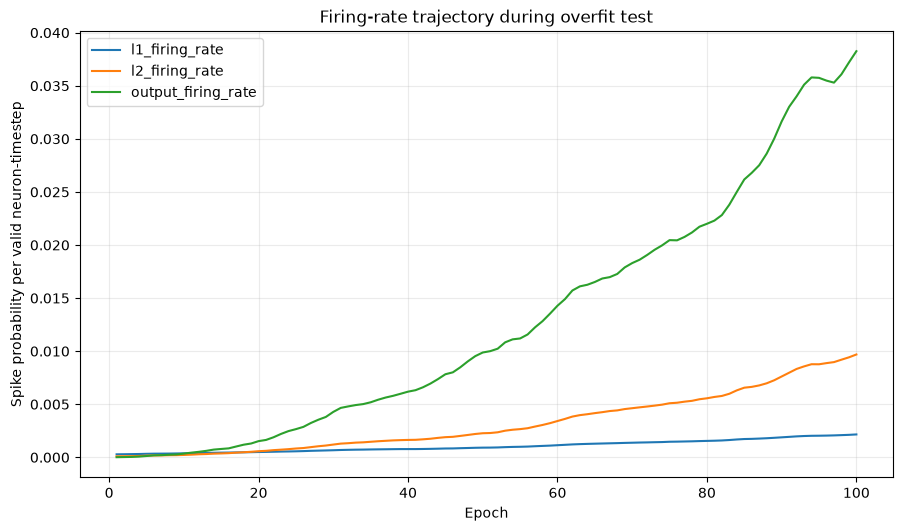

In [15]:
fig, ax = plt.subplots(figsize=(10.5, 5.8))
ax.plot(
    history["epoch"],
    history["train_balanced_accuracy"],
    marker="o",
    markersize=3,
)
ax.axhline(1.0 / NUM_CLASSES, linestyle="--", label="chance BA")
ax.axhline(PASS_TRAIN_BA, linestyle=":", label="pass threshold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Train balanced accuracy")
ax.set_title(f"Experiment 2.0 — Overfit sanity ({OVERFIT_OBJECTIVE})")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()

fig, ax = plt.subplots(figsize=(10.5, 5.8))
for metric in (
    "l1_firing_rate",
    "l2_firing_rate",
    "output_firing_rate",
):
    ax.plot(history["epoch"], history[metric], label=metric)

ax.set_xlabel("Epoch")
ax.set_ylabel("Spike probability per valid neuron-timestep")
ax.set_title("Firing-rate trajectory during overfit test")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


## 13. Save results

In [ ]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

history.to_csv(
    RESULTS_DIR / "experiment_2_0_overfit_history.csv",
    index=False,
)

summary = {
    "experiment_id": EXPERIMENT_ID,
    "objective": OVERFIT_OBJECTIVE,
    "passed": PASSED,
    "pass_train_ba": PASS_TRAIN_BA,
    "best_train_ba": float(best_train_ba),
    "best_epoch": int(best_epoch),
    "firing_onset_epoch": (
        None if firing_onset_epoch is None else int(firing_onset_epoch)
    ),
    "zero_input_before": zero_before,
    "zero_input_after": zero_after,
    "subset_samples": len(OVERFIT_MANIFEST),
    "samples_per_class": actual_per_class,
    "input_channels": INPUT_CHANNELS,
    "num_classes": NUM_CLASSES,
    "hidden_width": HIDDEN_WIDTH,
    "fixed_bin_ms": FIXED_BIN_MS,
    "tau_syn_ms": TAU_SYN_MS,
    "tau_mem_ms": TAU_MEM_MS,
    "threshold": THRESHOLD,
    "snn_linear_bias": False,
    "learning_rate": LEARNING_RATE,
    "epochs": OVERFIT_EPOCHS,
    "event_representation": EVENT_REPRESENTATION,
    "event_feature_schema": EVENT_FEATURE_SCHEMA,
    "encoder_spec_sha256": ENCODER_SPEC_SHA256,
}

with open(
    RESULTS_DIR / "experiment_2_0_overfit_summary.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Saved to:", RESULTS_DIR)


## Decision

- **Pass:** proceed to Experiment 2.1.
- **Fail + output FR ≈ 0:** still trapped in a silent regime; inspect threshold/input scale/surrogate-gradient operating point or learning rate before architecture sweeps.
- **Fail + healthy firing:** objective/optimization is more suspect than simple silence.
- **Zero-input firing > 0:** stop; with no SNN Linear bias this feed-forward baseline should remain silent under zero input.
